In [18]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_pinns import *


from load_metrics import load_metrics

In [37]:
def plot_loss_and_error(history_groups, colors, error_every=100, max_valid_steps=500):
    """
    Plot training loss and L2 error side-by-side for multiple solver groups.

    Args:
        history_groups: list of (history_dict, linestyle, alpha)
        colors: function taking int -> color
        error_every: frequency of l2_error recording (default every 100 epochs)
        max_valid_steps: max steps to plot if NaNs are detected
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey="row")
    ax_loss, ax_error, ax_error_pde, ax_error_bc = axes

    color_offset = 0

    for group_idx, (history_dict, linestyle, alpha) in enumerate(history_groups):
        for i, (slvr, metrics) in enumerate(history_dict.items()):
            #idx = color_offset + i
            idx = i

            # --- Loss ---
            loss_arr = np.array(metrics['train_loss'])

            nan = ''
            if np.isnan(np.min(loss_arr)):
                loss_arr = loss_arr[:max_valid_steps]
                nan = '(NaNs)'
                
            ax_loss.semilogy(
                loss_arr,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- Total Error ---
            errors = np.array(metrics.get('l2_error', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- PDE Error ---
            errors = np.array(metrics.get('l2_error_pde', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_pde.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- BC Error ---
            errors = np.array(metrics.get('l2_error_bc', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_bc.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

        color_offset += len(history_dict)

    ax_loss.set_title('Training Loss')
    ax_error.set_title('L2 Error')
    ax_error_pde.set_title('L2 Error (PDE)')
    ax_error_bc.set_title('L2 Error (BC)')

    
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.grid()
    
    ax.legend()

    plt.tight_layout()
    plt.show()


In [28]:
num_interior = 80 * 8
num_boundary = 20 * 2
interior_points, boundary_points = generate_training_data(num_interior, num_boundary)

dims = 256


NM = ((1,1), 
      #(1,2), (2,1), # sanity check
      (2,2), (3,3), #(4,4)
     )

problem_data = (interior_points, boundary_points)

def get_forcing_fxn(n, m):
    return lambda x: (n**2 + m**2) * (jnp.pi**2) * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])

def get_solution_fxn(n, m):
    return lambda x: jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])


path = "."
n_curves = len(NM)
colors = plt.cm.get_cmap('tab10', n_curves)

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_96312/2724462685.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_curves)


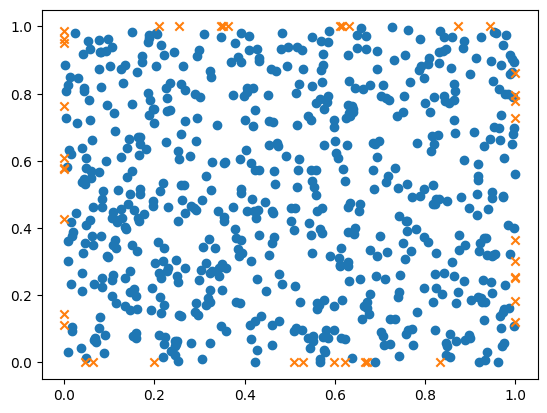

In [29]:
plt.scatter(interior_points[:,0], interior_points[:,1], marker='o')
plt.scatter(boundary_points[:,0], boundary_points[:,1], marker='x')

In [30]:

metrics_history_sgd = {}

for n,m in NM:

    name = f"{path}/sgd_fx_{n}_fy_{m}"    
    try:
        metrics_history_sgd[name] = load_metrics(f"{name}.pkl")
    
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        state, metrics = train_model(state,
                                     problem_data=problem_data,
                                     forcing_function=get_forcing_fxn(n, m),
                                     solution_function=get_solution_fxn(n, m),
                                     num_iterations=10000,
                                     lm_schedule=None,
                                     batch_size=200,
                                     metrics_file=name
                                     )
        
        metrics_history_sgd[name] = metrics


  0%|                                                                                             | 0/10000 [00:00<?, ?it/s, loss=56.8334]

(188, 2) (12, 2)


100%|█████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:41<00:00, 238.50it/s, loss=0.1412]



Training complete. Saving metrics to ./sgd_fx_1_fy_1.pkl...
Metrics saved successfully.


  0%|                                                                                                           | 0/10000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./sgd_fx_2_fy_2.pkl...
Metrics saved successfully.


  0%|                                                                                                           | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)


100%|██████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:40<00:00, 246.19it/s, loss=7560.7443]



Training complete. Saving metrics to ./sgd_fx_3_fy_3.pkl...
Metrics saved successfully.


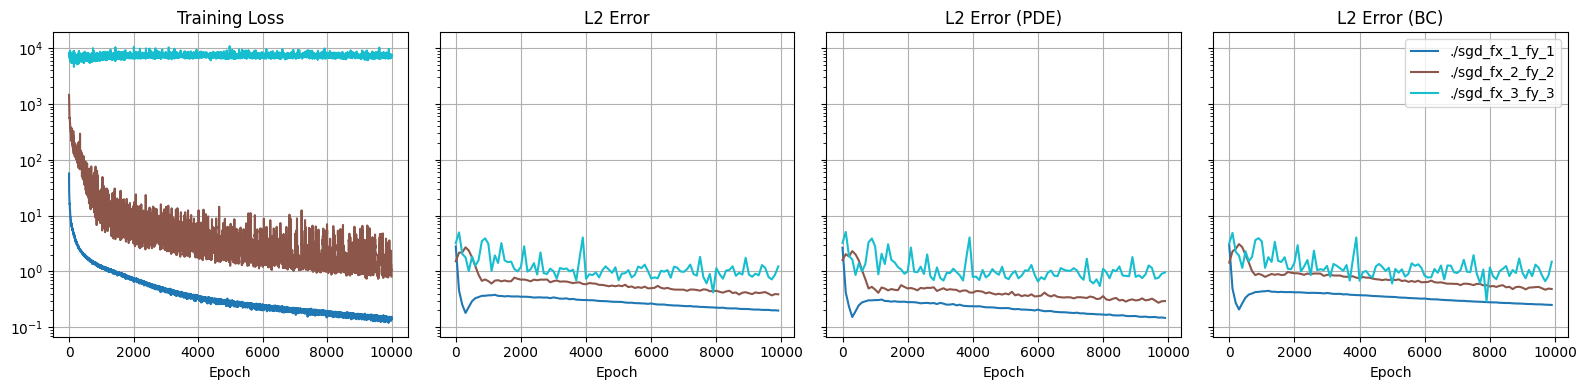

In [38]:
plot_specs = [
    (metrics_history_sgd, 'solid', 1.),
    #(metrics_history_sgd_epsilon, 'dashed', 0.5),
]

plot_loss_and_error(plot_specs, colors)

In [33]:
metrics_history_smw_lamb_1e1 = {}

lr = 2e-2
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

for n,m in NM:
    
    name = f"{path}/smw_fx_{n}_fy_{m}"
    
    try:
        metrics_history_smw_lamb_1e1[name] = load_metrics(f"{name}.pkl")
    
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        state, metrics = train_model(state,
                                     problem_data=problem_data,
                                     forcing_function=get_forcing_fxn(n, m),
                                     solution_function=get_solution_fxn(n, m),
                                     num_iterations=10000,
                                     lm_schedule=lm_info,
                                     batch_size=200,
                                     metrics_file=name,
                                     )
    
    
        metrics_history_smw_lamb_1e1[name] = metrics

  0%|                                                                                                           | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)
Running smw


100%|██████████████████████████████████████████████████████████████████████████████████| 10000/10000 [27:57<00:00,  5.96it/s, loss=0.0004]



Training complete. Saving metrics to ./smw_fx_1_fy_1.pkl...
Metrics saved successfully.


  0%|                                                                                                           | 0/10000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./smw_fx_2_fy_2.pkl...
Metrics saved successfully.


  0%|                                                                                                           | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)
Running smw


100%|█████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [28:56<00:00,  5.76it/s, loss=nan]



Training complete. Saving metrics to ./smw_fx_3_fy_3.pkl...
Metrics saved successfully.


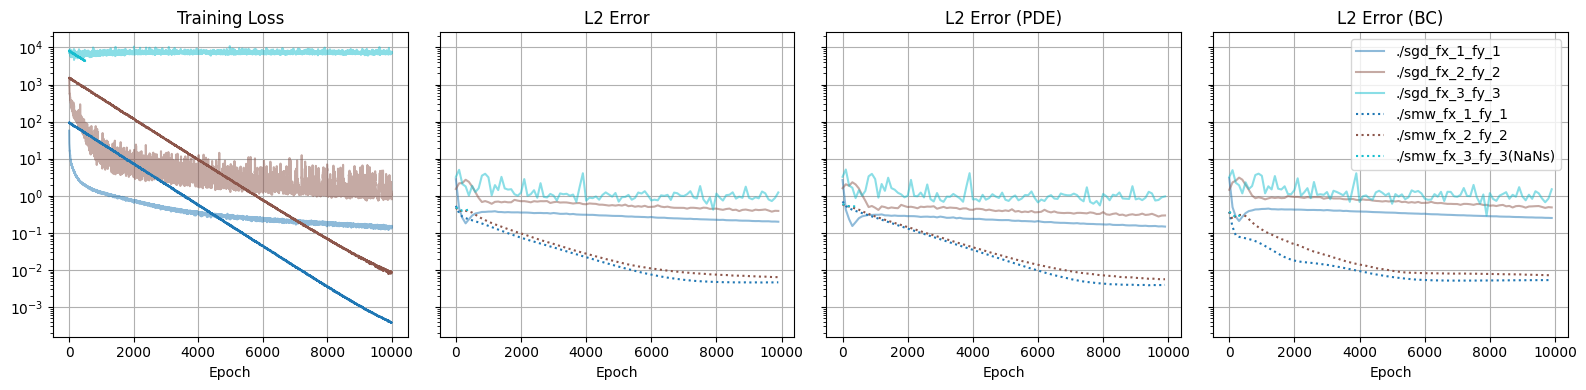

In [39]:

plot_specs = [
    (metrics_history_sgd, 'solid', 0.5),
    (metrics_history_smw_lamb_1e1, 'dotted', 1)
]

plot_loss_and_error(plot_specs, colors)


In [ ]:
# metrics_history_smw_lamb_1e2 = {}

# lr = 1e-2
# lm_info = PrecondData(
#     method='smw', epoch=0, lamb=1e-2,
# )

# for n,m in NM:
    
#     name = f"{path}/smw_fx_{n}_fy_{m}"
#     try:
#         metrics_history_smw_lamb_1e2[name] = load_metrics(f"{name}.pkl")
#     except:
#         model = MLP_1D(1, dims)
#         state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
#         state, metrics = train_model(
#                                     state,
#                                     problem_data=problem_data,
#                                     forcing_function=get_forcing_fxn(n, m),
#                                     solution_function=get_solution_fxn(n, m),
#                                     num_iterations=2000,
#                                     lm_schedule=lm_info,
#                                     batch_size=100,
#                                     metrics_file=name
#                                 )
        
#         metrics_history_smw_lamb_1e2[name] = metrics


In [ ]:

# plot_specs = [
#     (metrics_history_smw_lamb_1e1, 'solid', 0.5),
#     (metrics_history_smw_lamb_1e2, 'dotted', 1)
# ]

# plot_loss_and_error(plot_specs, colors)



In [40]:
metrics_history_gn = {}

lr = 5e-3
lm_info = PrecondData(
    method='gn-exact', epoch=0, thresh=1e-3,
)

for n,m in NM:
    name = f"{path}/gn_fx_{n}_fy_{m}"
    
    try:
        metrics_history_gn[name] = load_metrics(f"{name}.pkl")
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        
        state, metrics = train_model(
                                    state,
                                    problem_data=problem_data,
                                    forcing_function=get_forcing_fxn(n, m),
                                    solution_function=get_solution_fxn(n, m),
                                    num_iterations=5000,
                                    lm_schedule=lm_info,
                                    batch_size=100,
                                    metrics_file=name
                                )
        
        metrics_history_gn[name] = metrics


  0%|                                                                                                            | 0/5000 [00:00<?, ?it/s]

(94, 2) (6, 2)
Running gn-exact


100%|████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [10:47<00:00,  7.72it/s, loss=0.0994]



Training complete. Saving metrics to ./gn_fx_1_fy_1.pkl...
Metrics saved successfully.


  0%|                                                                                                            | 0/5000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./gn_fx_2_fy_2.pkl...
Metrics saved successfully.


  0%|                                                                                                            | 0/5000 [00:00<?, ?it/s]

(94, 2) (6, 2)
Running gn-exact


100%|███████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [09:39<00:00,  8.62it/s, loss=nan]



Training complete. Saving metrics to ./gn_fx_3_fy_3.pkl...
Metrics saved successfully.


In [ ]:

try:
    metrics_history_gn.pop('./gn_fx_4_fy_4')
except:
    pass


plot_specs = [
    (metrics_history_gn, 'solid', 0.5),
    (metrics_history_smw_lamb_1e2, 'dotted', 1)
]

plot_loss_and_error(plot_specs, colors, max_valid_steps=10)



